In [21]:
from utils import * 
import json
import itertools 
import networkx as nx
import subprocess
import seaborn as sns 
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import math 

%load_ext autoreload 
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0) # All genes passing the filters in analysis-1.ipynb
print('Number of genomes:', genes_df.genome_id.nunique())
print('Number of genes:', len(genes_df))
print('Number of Prodigal-predicted genes:', genes_df.prodigal_gene_id.dropna().nunique())
# copy_structures(genes_df.index, source_dir='../data/genes/colabfold/', output_dir='../data/genes/colabfold/genes')

reverse_complement_genome_ids = ['bz_0', 'bz_1', 'bz_4', 'bz_5', 'bz_7', 'bz_8','bz_12']

# for row in genes_df.itertuples():
#     if (row.genome_id in reverse_complement_genome_ids):
#         genes_df.loc[row.Index, 'start'] = row.genome_size - (row.stop + 1)
#         genes_df.loc[row.Index, 'stop'] = row.genome_size - (row.start - 1) 
#         genes_df.loc[row.Index, 'strand'] = '+' if (row.strand == '-') else '-'

INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
annot_df = annot_df[annot_df.gene_id.isin(genes_df.index)].copy()

Number of genomes: 12
Number of genes: 1633
Number of Prodigal-predicted genes: 429


In [23]:
MMSEQS_QUERY_PATH = '../data/genes/genes.faa'
MMSEQS_TARGET_PATH = MMSEQS_QUERY_PATH
MMSEQS_OUTPUT_PATH = '../data/genes/mmseqs/genes-genes.tsv'
MMSEQS_TMP_DIR = '../data/tmp/'
MMSEQS_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qcov,tcov,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch"'

MMSEQS_PARAMS = dict()
MMSEQS_PARAMS['-s'] = 9.5 # Maximum sensitiviy search. 
MMSEQS_PARAMS['-a'] = '' # Add a backtrace string. 
MMSEQS_PARAMS['--format-output'] = MMSEQS_FIELDS 

cmd = f'mmseqs easy-search {MMSEQS_QUERY_PATH} {MMSEQS_TARGET_PATH} {MMSEQS_OUTPUT_PATH} {MMSEQS_TMP_DIR}'
for param, value in MMSEQS_PARAMS.items():
    cmd += f' {param} {value}'
print(cmd)
# subprocess.run(cmd, shell=True, check=True)

mmseqs_df = pd.read_csv(MMSEQS_OUTPUT_PATH, names=MMSEQS_FIELDS.replace('"','').split(','), sep='\t')
mmseqs_df['pair_id'] = mmseqs_df.apply(lambda row : '-'.join(sorted([getattr(row, 'query'), getattr(row, 'target')])), axis=1)
mmseqs_df = mmseqs_df.sort_values('bits', ascending=False) # Sort by bits, with highest bitscores first. 

filters = dict()
filters['self_alignments'] = mmseqs_df['query'] == mmseqs_df['target']
filters['duplicate_pairs'] = mmseqs_df.pair_id.duplicated(keep='first') # Sorted by bits, so this will keep the best alignment.

mmseqs_df = apply_filters(filters, mmseqs_df)


mmseqs easy-search ../data/genes/genes.faa ../data/genes/genes.faa ../data/genes/mmseqs/genes-genes.tsv ../data/tmp/ -s 9.5 -a  --format-output "query,target,evalue,gapopen,pident,fident,nident,qcov,tcov,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch"
apply_filters: 1592 entries removed by self_alignments.
apply_filters: 773 entries removed by duplicate_pairs.


In [24]:
# print('Number of Foldseek alignments:', len(foldseek_df))
# print('Number of MMseqs alignments:', len(mmseqs_df))

# palette = {'MMseqs':'gray', 'Foldseek':'steelblue'}
# fig, ax = plt.subplots(figsize=(4, 3))

# figure_df = mmseqs_df[['bits', 'evalue']].assign(source='MMseqs')
# figure_df = pd.concat([figure_df, foldseek_df[['bits', 'evalue']].assign(source='Foldseek')])

# sns.kdeplot(figure_df, x='bits', hue='source', common_norm=False, palette=palette)

# for source, df in figure_df.groupby('source'):
#     mean = df['bits'].mean()
#     ax.axvline(df['bits'].mean(), ls='--', color=palette.get(source))
#     ax.text(mean, ax.get_ylim()[-1], str(int(mean)), ha='center')


# ax.get_legend().set_title('')
# ax.set_xlim(xmax=500, xmin=0)

# plt.show()


In [25]:
graph = nx.Graph()
filter_ = (mmseqs_df.qcov > 0.75) & (mmseqs_df.tcov > 0.75)
filter_ = filter_ & (mmseqs_df.bits > 40)

edges = [(row.query, row.target) for row in mmseqs_df[filter_].itertuples()]
# edges += [(row.query, row.target) for row in foldseek_df[filter_].itertuples()]
graph.add_edges_from(edges)
graph.add_nodes_from(genes_df.index.values)

clusters = list(nx.connected_components(graph))
clusters = sorted(clusters, key=len)[::-1]
clusters = {i:cluster for i, cluster in enumerate(clusters)}

cluster_df = pd.DataFrame.from_dict({gene_id:i for i, cluster in clusters.items() for gene_id in cluster}, orient='index', columns=['cluster_id'])
cluster_df = cluster_df.reset_index(names='gene_id')
cluster_df['genome_id'] = cluster_df.gene_id.apply(get_genome_id)
cluster_df = cluster_df[cluster_df.genome_id != 'bz_12'].copy()
cluster_df['cluster_num_genomes'] = cluster_df.groupby('cluster_id').genome_id.transform('nunique')
cluster_df['cluster_size'] = cluster_df.groupby('cluster_id').transform('size')

genes_df = genes_df.drop(columns=cluster_df.columns, errors='ignore')
genes_df = genes_df.merge(cluster_df.set_index('gene_id'), left_index=True, right_index=True, how='inner')
genes_df['length'] = genes_df.seq.apply(len)

with open('../data/genes/clusters.json', 'w') as f:
    json.dump(genes_df.cluster_id.to_dict(), f)



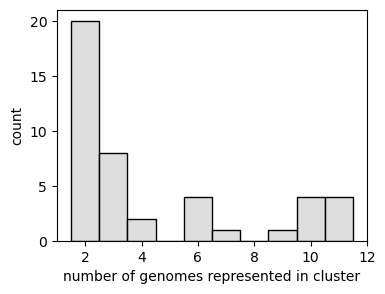

Number of clusters in 9 genomes: 1
Number of clusters in 10 genomes: 4
Number of clusters in 11 genomes: 4

Maximum number of cluster_14 genes in a genome: 1
Maximum number of cluster_15 genes in a genome: 1
Maximum number of cluster_17 genes in a genome: 1
Maximum number of cluster_18 genes in a genome: 1
Maximum number of cluster_19 genes in a genome: 1
Maximum number of cluster_20 genes in a genome: 1
Maximum number of cluster_21 genes in a genome: 1
Maximum number of cluster_23 genes in a genome: 1
Maximum number of cluster_24 genes in a genome: 1
Maximum number of cluster_25 genes in a genome: 1
Maximum number of cluster_27 genes in a genome: 1
Maximum number of cluster_28 genes in a genome: 1
Maximum number of cluster_29 genes in a genome: 1
Maximum number of cluster_31 genes in a genome: 1
Maximum number of cluster_33 genes in a genome: 1
Maximum number of cluster_34 genes in a genome: 1
Maximum number of cluster_35 genes in a genome: 1
Maximum number of cluster_39 genes in a ge

In [26]:
fig, ax = plt.subplots(figsize=(4, 3))

figure_df = cluster_df.drop_duplicates('cluster_id').copy()
figure_df = figure_df[figure_df.cluster_num_genomes > 1].copy()

# sns.histplot(figure_df, x='cluster_size', discrete=True, alpha=0.5, color='gray')
sns.histplot(figure_df, x='cluster_num_genomes', discrete=True, color='lightgray')
ax.set_ylabel('count')
ax.set_xlabel('number of genomes represented in cluster')
plt.show()

print('Number of clusters in 9 genomes:', (figure_df.cluster_size == 9).sum())
print('Number of clusters in 10 genomes:', (figure_df.cluster_size == 10).sum())
print('Number of clusters in 11 genomes:', (figure_df.cluster_size == 11).sum(), end='\n\n')

level_1_conserved_cluster_ids = genes_df[genes_df.cluster_num_genomes > 8].cluster_id.unique().tolist()
level_2_conserved_cluster_ids = genes_df[(genes_df.cluster_num_genomes < 9) & (genes_df.cluster_num_genomes > 5)].cluster_id.unique().tolist()
level_3_conserved_cluster_ids = genes_df[(genes_df.cluster_num_genomes < 6) & (genes_df.cluster_num_genomes > 1)].cluster_id.unique().tolist()
conserved_cluster_ids = level_1_conserved_cluster_ids + level_2_conserved_cluster_ids + level_3_conserved_cluster_ids

genes_df['conserved'] = genes_df.cluster_id.isin(conserved_cluster_ids)

# level_1_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_1_conserved_cluster_ids} 
# level_2_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_2_conserved_cluster_ids} 
# level_3_conserved_cluster_gene_ids = {i:genes_df[genes_df.cluster_id == i].index.values for i in level_3_conserved_cluster_ids} 

for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_3_conserved_cluster_ids)].groupby('cluster_id'):
    print(f'Maximum number of cluster_{cluster_id} genes in a genome:', df.genome_id.value_counts().max())

In [27]:
# print('Highly-conserved cluster IDs:', level_1_conserved_cluster_ids.tolist())
# print('Moderately-conserved cluster IDs:', level_2_conserved_cluster_ids.tolist())
# print('Weakly-conserved cluster IDs:', level_3_conserved_cluster_ids.tolist())

print('level_1_conserved_cluster_ids =', level_1_conserved_cluster_ids)
print('level_2_conserved_cluster_ids =', level_2_conserved_cluster_ids)
print('level_3_conserved_cluster_ids =', level_3_conserved_cluster_ids)

level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]


In [28]:
def is_valid_structure(plddts:list, min_plddt:float=70, window_size:int=50, step_size:int=3):
    '''Determines if a structure prediction is sufficient for meaningful Foldseek results.
     
    :param plddts: Per-residue pLDDT from ColabFold output. 
    :param min_plddt: The minimum average pLDDT required to consider the structure prediction for a window to be "valid."
    :param window_size: The size of the window over which to compute the average pLDDT. 
    :param step_size: The increment for the sliding window. 
    :returns: A boolean value indicating if the structure is reasonable. 
    '''
    if len(plddts) < window_size:
        return False 
    for i in range(0, len(plddts) - window_size + 1, step_size):
        if np.mean(plddts[i:i + window_size]) > min_plddt:
            return True 
    return False

In [29]:
colabfold_metadata_df = pd.read_csv('analysis-1-structs_colabfold_metadata.csv', usecols=['name', 'plddts_best_model'])
colabfold_metadata_df['plddts_best_model'] = colabfold_metadata_df.plddts_best_model.apply(ast.literal_eval)
colabfold_metadata_df = colabfold_metadata_df.rename(columns={'name':'gene_id'}).set_index('gene_id')
colabfold_metadata_df['valid_structure'] = colabfold_metadata_df.plddts_best_model.apply(is_valid_structure)

In [30]:
genes_df['conserved'] = genes_df.cluster_num_genomes > 1
genes_df['has_annotation'] = genes_df.index.isin(annot_df.gene_id.unique())
genes_df['has_valid_structure'] = colabfold_metadata_df.valid_structure
genes_df['predicted_by_prodigal'] = ~genes_df.prodigal_gene_id.isnull()
# genes_df['supported'] = (genes_df.conserved | genes_df.has_annotation | genes_df.predicted_by_prodigal)
genes_df['supported'] = genes_df.conserved | genes_df.has_annotation | genes_df.has_valid_structure | genes_df.predicted_by_prodigal

print('Number supported genes:', genes_df.supported.sum(), 'out of', len(genes_df), end='\n\n')

# There are 106 total genes which have a "valid" structure and do not meet the other "supported" requirements. Because some of these genes are of 
# reasonable length (> 100 residues), I opted to include them in the "supported" group. However, it is worth being cautious in case the folds are hallucinated.
# print('Number of unsupported genes with a valid structure:', (~genes_df.supported & genes_df.has_valid_structure).sum())

for genome_id, df in genes_df.groupby('genome_id'):
    print(f'Number of supported genes in {genome_id}:', df.supported.sum(), 'versus', df.predicted_by_prodigal.sum(), 'predicted by Prodigal')

with open('analysis-1-cluster-supported_gene_ids.txt', 'w') as f:
    np.savetxt(f, genes_df[genes_df.supported].index.values.astype(str), fmt='%s')

Number supported genes: 536 out of 1528

Number of supported genes in bz_0: 53 versus 38 predicted by Prodigal
Number of supported genes in bz_1: 43 versus 34 predicted by Prodigal
Number of supported genes in bz_10: 39 versus 31 predicted by Prodigal
Number of supported genes in bz_11: 41 versus 30 predicted by Prodigal
Number of supported genes in bz_2: 36 versus 31 predicted by Prodigal
Number of supported genes in bz_3: 49 versus 36 predicted by Prodigal
Number of supported genes in bz_4: 55 versus 45 predicted by Prodigal
Number of supported genes in bz_5: 45 versus 33 predicted by Prodigal
Number of supported genes in bz_7: 53 versus 32 predicted by Prodigal
Number of supported genes in bz_8: 66 versus 47 predicted by Prodigal
Number of supported genes in bz_9: 56 versus 45 predicted by Prodigal


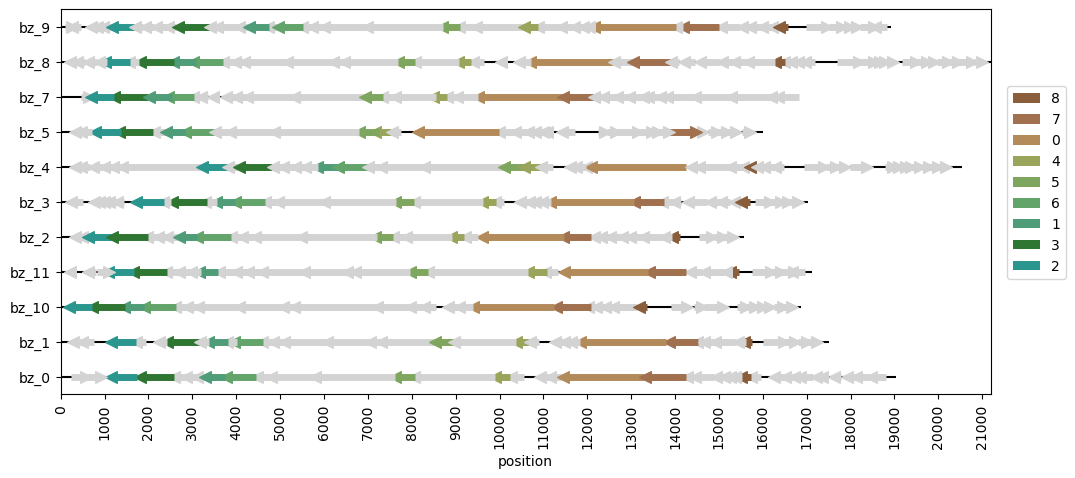

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#8A5E3B', '#A0704F', '#B38A5A', '#9AA45A', '#7FA65E', '#62A46A', '#4F9D78', "#2F7632", "#2B968E", "#5691D8", "#323986"]
palette = dict(zip(level_1_conserved_cluster_ids, colors))

figure_df = genes_df[genes_df.supported].copy()
figure_df['gene_id'] = figure_df.index
# figure_df = genes_df[genes_df.cluster_id.isin(palette)].copy()
figure_df = figure_df.reset_index(drop=True)
figure_df = figure_df[~figure_df.prodigal_gene_id.isnull()].copy()


plot_orfs(figure_df, ax=ax, palette=palette)

labels = level_1_conserved_cluster_ids
handles = [Patch(facecolor=palette[cluster_id], label=cluster_id) for cluster_id in labels]
ax.legend(handles, labels, bbox_to_anchor=(1.01, 0.55), loc='center left')
plt.show()


In [34]:
for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].groupby('cluster_id'):
    info = f'cluster_{cluster_id}'
    info += f'\tlengths: {df.length.min()} - {df.length.max()}'
    info += f'\tany/all predicted by Prodigal: {np.any(~df.prodigal_gene_id.isnull())}/{np.all(~df.prodigal_gene_id.isnull())}'
    print(info)
# mmseqs_df[mmseqs_df['query'].isin(cluster_0_gene_ids) & mmseqs_df['target'].isin(cluster_0_gene_ids)]

cluster_0	lengths: 610 - 715	any/all predicted by Prodigal: True/True
cluster_1	lengths: 138 - 153	any/all predicted by Prodigal: True/True
cluster_2	lengths: 173 - 196	any/all predicted by Prodigal: True/True
cluster_3	lengths: 244 - 266	any/all predicted by Prodigal: True/True
cluster_4	lengths: 90 - 125	any/all predicted by Prodigal: True/True
cluster_5	lengths: 126 - 149	any/all predicted by Prodigal: True/True
cluster_6	lengths: 177 - 253	any/all predicted by Prodigal: True/True
cluster_7	lengths: 207 - 311	any/all predicted by Prodigal: True/True
cluster_8	lengths: 53 - 69	any/all predicted by Prodigal: True/True


In [35]:
INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']

annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
annot_df['cluster_id'] = annot_df.gene_id.map(cluster_df.set_index('gene_id').cluster_id)

annot_df[annot_df.cluster_id == 7]
genes_df[genes_df.cluster_id == 7]


,nt_seq,description,seq,frame,gene_number,start,stop,strand,partial,has_start_codon,...,cluster_id,genome_id,cluster_num_genomes,cluster_size,length,conserved,has_annotation,has_valid_structure,predicted_by_prodigal,supported
gene_id,,,,,,,,,,,,,,,,,,,,,
orfm.bz_0.1_82,ATGGTATCTTCAAGTTATCAATCAAAACAACATAAAACTTCTTATC...,NaN,MVSSSYQSKQHKTSYHPVKKPAKITGTSYFSQRKLRAGISSYQPQR...,1,82,13309,14247,-,False,True,...,7,bz_0,10,10,311,True,True,True,True,True
orfm.bz_1.1_43,GTGCACATGAAAAAAATAAAAATAAATATTATCTCTAAAACAGGTT...,NaN,VHMKKIKINIISKTGSIQKREIKKDNLIFYERKGKYYIKKEKIKIS...,2,43,13862,14530,-,False,True,...,7,bz_1,10,10,218,True,False,False,True,True
orfm.bz_2.1_117,ATGGCACGAAAAGTATATGATTTTCCTTTATTTAAATTGGAAGAAT...,NaN,MARKVYDFPLFKLEELAKEKNLKLYKSAFKEESQYKAYIEFKKRQK...,5,117,11449,12079,-,False,True,...,7,bz_2,10,10,208,True,True,False,True,True
orfm.bz_3.1_142,ATGAAAAAAATTTTAATTAAAATATTACAAAAAAATAATATAATTT...,NaN,MKKILIKILQKNNIISSRNIQKSNKKFYIYDRKIKAYRKKSKIEIS...,4,142,13059,13758,-,False,True,...,7,bz_3,10,10,218,True,True,False,True,True
orfm.bz_5.1_26,ATGAGCAAATCTAAATATATTCAAATTTCAATTATTAACAAGAAAG...,NaN,MSKSKYIQISIINKKGKKTLVTILRKNKKNYIRDSELKGLIKIPVK...,4,26,13838,14482,+,False,True,...,7,bz_5,10,10,207,True,False,False,True,True
orfm.bz_7.1_68,ATGACAAAAGATAAATACATAACAATAAAACTTATTACAAAAAATA...,NaN,MTKDKYITIKLITKNNKVQTRKVKKAILKQYVKTKEGYYRKKIPVI...,1,68,11452,12144,-,False,True,...,7,bz_7,10,10,228,True,False,False,True,True
orfm.bz_8.1_106,TTGGTAATAAAAGCAGATGATATAGAACGTATAAAACAATTACGTA...,NaN,LVIKADDIERIKQLRKAGKTGSQISKEIHKRKSETLRIIRIIESKK...,1,106,13034,13924,-,False,True,...,7,bz_8,10,10,288,True,True,True,True,True
orfm.bz_9.1_152,ATGGTAAACATAGAAAAAATAAAAGAATTAAGAAGTAAGGGTTTTT...,NaN,MVNIEKIKELRSKGFSGSKIAKELHLRKQVTLQIIREIEHRKKPKS...,5,152,14173,14992,-,False,True,...,7,bz_9,10,10,272,True,False,False,True,True
orfm.bz_10.1_110,ATGATTACAAATGAAGATAGAAAAAATATAAAGCGATATATTGAAG...,NaN,MITNEDRKNIKRYIEEEKTGKEIAVLIHKRYQTVLDEIRNIKNVPK...,6,110,11285,12074,-,False,True,...,7,bz_10,10,10,246,True,True,False,True,True


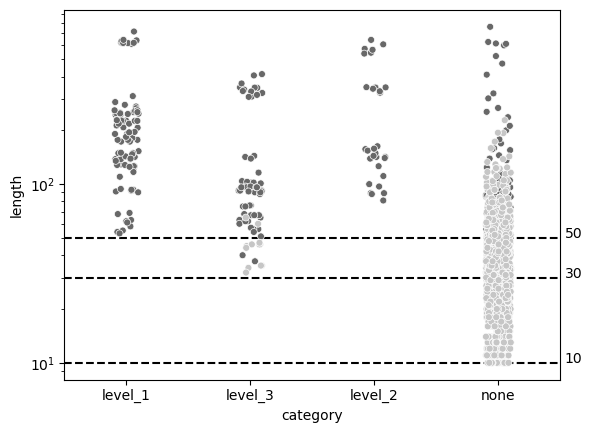

In [36]:
fig, ax = plt.subplots()

figure_df = genes_df.copy()

categories = dict()
categories['level_1'] = figure_df.index.isin(genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].index)
categories['level_2'] = figure_df.index.isin(genes_df[genes_df.cluster_id.isin(level_2_conserved_cluster_ids)].index)
categories['level_3'] = figure_df.index.isin(genes_df[genes_df.cluster_id.isin(level_3_conserved_cluster_ids)].index)

categories, conditions = list(zip(*categories.items()))
figure_df['category'] = np.select(conditions, categories, default='none')
figure_df['prodigal_predicted'] = ~figure_df.prodigal_gene_id.isnull()
figure_df = figure_df.sort_values('prodigal_predicted', ascending=False)

sns.stripplot(figure_df, x='category', y='length', palette='Grays', hue='prodigal_predicted', edgecolor='white', linewidth=0.5, legend=False)

for y in [10, 30, 50]:
    ax.axhline(y, ls='--', color='black')
    ax.text(ax.get_xlim()[-1] * 1.01, y, str(y))
ax.set_yscale('log')

In [37]:
# What is the minimum bit score for alignments between members of the same cluster?
# This is to inform the parameters to use when filtering the BLAST hits for custom MSA building. 

for cluster_id, df in genes_df[genes_df.cluster_id.isin(level_1_conserved_cluster_ids)].groupby('cluster_id'):
    gene_ids = df.index.values 
    mmseqs_df_ = mmseqs_df[mmseqs_df['query'].isin(gene_ids) & mmseqs_df['target'].isin(gene_ids)].copy() # Self-alignments and duplicate alignments have already been removed. 
    n_alignments = len(mmseqs_df_)
    n_possible_alignments = math.comb(len(gene_ids), 2)

    print(f'Minimum percent identity for cluster {int(cluster_id)}:', mmseqs_df_.pident.min(), f'with {n_alignments} out of {n_possible_alignments} alignments made.')
    # print(f'Minimum bit score for cluster {cluster_id}:', mmseqs_df_.bits.min(), f'with {n_alignments} out of {n_possible_alignments} alignments made.')
    # print(f'Maximum E-value for cluster {cluster_id}:', mmseqs_df_.evalue.max(), f'with {n_alignments} out of {n_possible_alignments} alignments made.') # E-value is kind of useless because it is database-dependent. 

Minimum percent identity for cluster 0: 23.4 with 55 out of 55 alignments made.
Minimum percent identity for cluster 1: 25.3 with 53 out of 55 alignments made.
Minimum percent identity for cluster 2: 23.7 with 55 out of 55 alignments made.
Minimum percent identity for cluster 3: 34.2 with 55 out of 55 alignments made.
Minimum percent identity for cluster 4: 25.2 with 37 out of 45 alignments made.
Minimum percent identity for cluster 5: 26.9 with 45 out of 45 alignments made.
Minimum percent identity for cluster 6: 21.2 with 42 out of 45 alignments made.
Minimum percent identity for cluster 7: 24.0 with 44 out of 45 alignments made.
Minimum percent identity for cluster 8: 32.0 with 34 out of 36 alignments made.


In [38]:
genes_df = genes_df[(~genes_df.prodigal_gene_id.isnull()) | genes_df.conserved].copy()

INTERPROSCAN_FIELDS = ['gene_id', 'checksum', 'length', 'analysis', 'signature_accession', 'signature_description', 'annotation_start','annotation_stop', 'annotation_e_value', 'annotation_status', 'date', 'interpro_accession', 'interpro_description', 'go_terms', 'pathways']
annot_df = pd.read_csv('../data/genes/interproscan/genes.tsv', sep='\t', header=None, names=INTERPROSCAN_FIELDS)
annot_df = annot_df[annot_df.gene_id.isin(genes_df.index)].copy()

filters = dict()
filters['consensus_disorder_prediction'] = annot_df.signature_accession == 'mobidb-lite'
filters['coil'] = annot_df.signature_accession == 'Coil'

annot_df = apply_filters(filters, annot_df)
annot_df['conserved'] = annot_df.gene_id.map(genes_df.conserved)

annot_df.conserved.value_counts()
annot_df[~annot_df.conserved]



# orfm.bz_0.1_132 Carobxypeptidase, cleaves the C-terminal portion of proteins. 

# orfm.bz_1.1_91 NodB homology domain; this is some kind of deacetylase. 

# orfm.bz_8.1_75 Ribonuclease. 
# orfm.bz_8.1_29 GNAT family acetyltransferase
# orfm.bz_8.1_110 Phosphohydrolase, MazG-like. https://pmc.ncbi.nlm.nih.gov/articles/PMC3855555/

# orfm.bz_7.1_37 Pentapeptide repeats. 
# orfm.bz_7.1_18 Pentapeptide repeats. 
# orfm.bz_7.1_56 Is possibly related to lipid biogenesis, but otherwise uncharacterized. https://www.ebi.ac.uk/interpro/entry/pfam/PF18902/
# orfm.bz_7.1_95 Another ATPase. 
# orfm.bz_7.1_5 This family of proteins includes various functions such as cell adhesion, biofilm formation, and virulence in pathogens. Some members act as chaperones facilitating protein secretion, while others are involved in invasive growth and cell-cell adhesion.

# orfm.bz_9.1_111 Fibronectin, involved in cell adhesion. 

# orfm.bz_11.1_108 Pectin lyase, helps degrade cell walls https://www.ebi.ac.uk/interpro/entry/InterPro/IPR012334/

apply_filters: 16 entries removed by consensus_disorder_prediction.
apply_filters: 22 entries removed by coil.


,gene_id,checksum,length,analysis,signature_accession,signature_description,annotation_start,annotation_stop,annotation_e_value,annotation_status,date,interpro_accession,interpro_description,go_terms,pathways,conserved
25,orfm.bz_7.1_56,ee79e7680a69558660e08f021857b41a,115,Pfam,PF18902,Domain of unknown function (DUF5658),15,99,6.3E-7,T,16-06-2026,IPR043717,Domain of unknown function DUF5658,-,-,False
38,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,ProSiteProfiles,PS51677,NodB homology domain profile.,192,473,14.8961,T,16-06-2026,IPR002509,NodB homology domain,-,-,False
39,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,Pfam,PF01522,Polysaccharide deacetylase,193,302,1.6E-13,T,16-06-2026,IPR002509,NodB homology domain,-,-,False
40,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,SUPERFAMILY,SSF88713,Glycoside hydrolase/deacetylase,193,416,2.78E-20,T,16-06-2026,IPR011330,"Glycoside hydrolase/deacetylase, beta/alpha-ba...",-,-,False
41,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,PANTHER,PTHR34216,-,193,328,1.1E-21,T,16-06-2026,IPR051398,Polysaccharide Deacetylase,-,-,False
42,orfm.bz_1.1_91,db1e6e93cd961728898abee11102f542,473,Gene3D,G3DSA:3.20.20.370,Glycoside hydrolase/deacetylase,165,349,7.1E-25,T,16-06-2026,-,-,-,-,False
76,orfm.bz_8.1_110,fca83d1db83b4049f85bf892393c9d94,139,Gene3D,G3DSA:1.10.287.1080,-,20,135,9.0E-15,T,16-06-2026,-,-,-,-,False
77,orfm.bz_8.1_110,fca83d1db83b4049f85bf892393c9d94,139,Pfam,PF03819,MazG nucleotide pyrophosphohydrolase domain,77,132,0.14,T,16-06-2026,IPR004518,NTP pyrophosphohydrolase MazG-like domain,-,-,False
78,orfm.bz_8.1_110,fca83d1db83b4049f85bf892393c9d94,139,SUPERFAMILY,SSF101386,all-alpha NTP pyrophosphatases,67,132,1.64E-12,T,16-06-2026,-,-,-,-,False
80,orfm.bz_7.1_5,784a8d1e900c378dc033a90c6b2a5d53,157,PANTHER,PTHR10068,BONE MARROW PROTEOGLYCAN,24,128,8.5E-14,T,16-06-2026,-,-,-,-,False


In [39]:
# FOLDSEEK_QUERY_PATH = '../data/genes/colabfold/genes/'
# FOLDSEEK_TARGET_PATH = FOLDSEEK_QUERY_PATH
# FOLDSEEK_OUTPUT_PATH = '../data/genes/foldseek/genes-genes.tsv'
# FOLDSEEK_TMP_DIR = '../data/tmp/'
# FOLDSEEK_FIELDS = '"query,target,evalue,gapopen,pident,fident,nident,qstart,qend,qlen,tstart,tend,tlen,alnlen,bits,cigar,qseq,tseq,qheader,theader,qaln,taln,mismatch,qcov,tcov,lddt,lddtfull,qtmscore,ttmscore,alntmscore,rmsd,prob"'

# FOLDSEEK_PARAMS = dict()
# FOLDSEEK_PARAMS['-s'] = 9.5 # Maximum sensitiviy search. 
# FOLDSEEK_PARAMS['--alignment-type'] = 1 # Make sure to actually align the structures.
# FOLDSEEK_PARAMS['-a'] = '' # Add a backtrace string. 
# FOLDSEEK_PARAMS['--format-output'] = FOLDSEEK_FIELDS 

# cmd = f'foldseek easy-search {FOLDSEEK_QUERY_PATH} {FOLDSEEK_TARGET_PATH} {FOLDSEEK_OUTPUT_PATH} {FOLDSEEK_TMP_DIR}'
# for param, value in FOLDSEEK_PARAMS.items():
#     cmd += f' {param} {value}'
# print(cmd)
# # subprocess.run(cmd, shell=True, check=True)

# foldseek_df = pd.read_csv(FOLDSEEK_OUTPUT_PATH, names=FOLDSEEK_FIELDS.replace('"','').split(','), sep='\t')
# foldseek_df['pair_id'] = foldseek_df.apply(lambda row : '-'.join(sorted([getattr(row, 'query'), getattr(row, 'target')])), axis=1)
# foldseek_df = foldseek_df.sort_values('bits', ascending=False) # Sort by bits, with highest bitscores first. 

# filters = dict()
# filters['self_alignments'] = foldseek_df['query'] == foldseek_df['target']
# filters['duplicate_pairs'] = foldseek_df.pair_id.duplicated(keep='first') # Sorted by bits, so this will keep the best alignment.

# foldseek_df = apply_filters(filters, foldseek_df)

